In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


>>> Run: SGD
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7485 - loss: 0.7137 - val_accuracy: 0.8170 - val_loss: 0.5021
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8444 - loss: 0.4366 - val_accuracy: 0.8550 - val_loss: 0.4130
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8627 - loss: 0.3856 - val_accuracy: 0.8660 - val_loss: 0.3717
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8695 - loss: 0.3616 - val_accuracy: 0.8672 - val_loss: 0.3735
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8775 - loss: 0.3396 - val_accuracy: 0.8735 - val_loss: 0.3505

>>> Run: Adam
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7798 - loss: 0.6429 - val_accuracy: 0.8383 - val_loss: 0.4488
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8554 - loss: 0.4146 - val_accuracy: 0.8572 - val_loss: 0.3878
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8630 - loss: 0.38

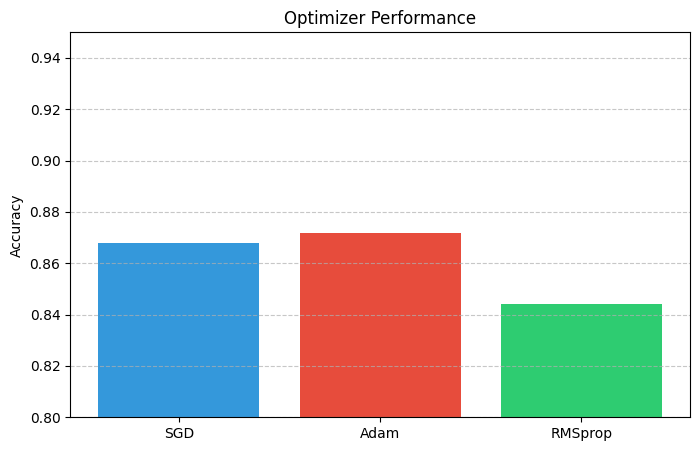

In [11]:


(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

def get_model():
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

optimizers = {
    "SGD": keras.optimizers.SGD(0.05, momentum=0.9),
    "Adam": keras.optimizers.Adam(0.001),
    "RMSprop": keras.optimizers.RMSprop(0.001)
}

history_data = {}

for name, opt in optimizers.items():
    print(f"\n>>> Run: {name}")
    
    model = get_model()
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=512,
        validation_split=0.1,
        verbose=1
    )
    
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    history_data[name] = acc

print("\nSummary:")
for name, score in history_data.items():
    print(f"{name:8}: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(history_data.keys(), history_data.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.ylim(0.8, 0.95)
plt.title("Optimizer Performance")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()